# Matemáticas aplicadas. Practica Final

#### Samuel Acosta Aristizábal - 1000900513
#### Manuela Caro Villada - 1000124254
#### Jeronimo Velasquez Escobar - 1000116682

In [190]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns


### Objetivo
Integrar herramientas de álgebra lineal multivariada, métricas de distancia y optimización convexa para
transformar datos no estructurados (imágenes) en un espacio latente de baja dimensión, detectar valores atípicos mediante matrices de covarianza, y entrenar matemáticamente un clasificador binario construyendo sus propios algoritmos de descenso de gradiente.

In [191]:
# Datos a utilizar en el examen
from sklearn.datasets import fetch_olivetti_faces as olivetti
Original_data = olivetti()

data.keys(): dict_keys(['data', 'images', 'target', 'DESCR'])
data['images'].shape: (400, 64, 64)
data['target'].shape: (400,)
data['images'][0].shape: (64, 64)
data['data']: (400, 4096)


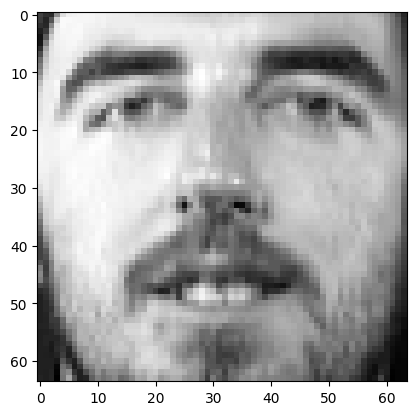

In [192]:
# Visualizamos la data
print("data.keys():", Original_data.keys())
print("data['images'].shape:", Original_data['images'].shape)
print("data['target'].shape:", Original_data['target'].shape)
print("data['images'][0].shape:", Original_data['images'][0].shape)
print("data['data']:", Original_data['data'].shape)
# Visualizamos una imagen
plt.imshow(Original_data['images'][100], cmap='gray')

In [193]:
Original_data['data'].shape # Esta es la data ya aplanana dimensiones 400 x 4096
datos = Original_data['data'].copy() # Hacemos una copia de la data para no modificar la original
datos.shape

(400, 4096)

Ancla: [0.7231405  0.7231405  0.72727275 ... 0.22727273 0.21900827 0.21900827]


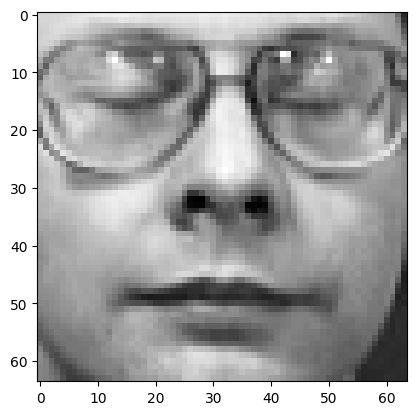

In [194]:
# Tarea 1 punto a)

# Se Selecciona el ancla

ancla = datos[38]
print("Ancla:", ancla)

# Se calcula la distancia euclidiana entre el ancla y cada una de las otras imágenes, con operaciones basicas
L2 = np.sqrt(np.sum((datos - ancla) ** 2, axis=1))
plt.imshow(ancla.reshape(64, 64), cmap='gray')


In [195]:
# Se calcula la similitud coseno entre el ancla y cada una de las otras imágenes, con operaciones basicas
cosine_similarity = (np.sum(datos * ancla, axis=1) / (np.linalg.norm(datos, axis=1) * np.linalg.norm(ancla)))

In [196]:
# Seleccionamos las 3 imágenes más similares al ancla según la distancia euclidiana
indices_euclidianos = np.argsort(L2)[1:4] # Excluimos el primer elemento que es el ancla
print("Índices de las 3 imágenes más similares según distancia euclidiana:", indices_euclidianos)
indices_por_coseno = np.argsort(cosine_similarity)[-4:-1] # Excluimos el primer elemento que es el ancla
print("Índices de las 3 imágenes más similares según similitud coseno:", indices_por_coseno)

Índices de las 3 imágenes más similares según distancia euclidiana: [ 31 208 149]
Índices de las 3 imágenes más similares según similitud coseno: [34 31 33]


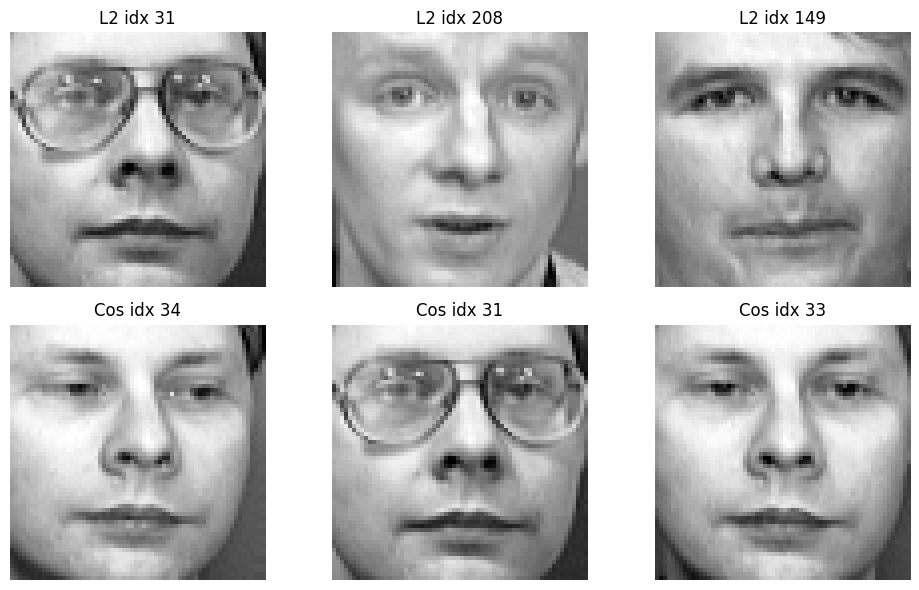

In [197]:
# Visualizamos las imagenes relacionadas al ancla por distancia euclidiana
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(10, 6))

# Primera fila: L2
for i, idx in enumerate(indices_euclidianos):
    axes[0, i].imshow(datos[idx].reshape(64, 64), cmap='gray')
    axes[0, i].set_title(f"L2 idx {idx}")
    axes[0, i].axis('off')

# Segunda fila: Coseno
for i, idx in enumerate(indices_por_coseno):
    axes[1, i].imshow(datos[idx].reshape(64, 64), cmap='gray')
    axes[1, i].set_title(f"Cos idx {idx}")
    axes[1, i].axis('off')



plt.tight_layout()
plt.show()

#### Tarea 1 

D) Discusion. No, las imagenes mas cercanas no siempre provienen de la misma persona, realizamos la prueba con distintas anclas y en algunos casos ambas distancias nos mostraban los mismos vectores mas cercanos y en otras los vectores mas cercanos no se correspondian como se puede observar en la imagen anterior. Podemos nuentra ancla es el numero 38 lo que nos dice que esta persona va ser la misma si los indices de los vectores van de entre 30 a el 39. Con la distancia euclidiana solamente uno de los vectores mas proximos es el que aparece, este siendo especificamente el veector con indice 31. Por otro lado el resto de imagenes no pertenece a la misma persona. Estos errores tan grandees no se presentan en la distancia de el coseno

¿Por qué la distancia Euclidiana directa sobre píxeles es estadísticamente frágil si la persona mueve ligeramentela cabeza o hay un cambio global en la iluminación?

La razon es porque trata cada píxel como una variable independiente y suma las diferencias cuadráticas en las 4096 dimensiones. Pequeños desplazamientos del rostro o cambios globales de iluminación alteran simultáneamente muchos píxeles, lo que incrementa artificialmente la distancia aun cuando la identidad visual sea la misma. En espacios de alta dimensión, estas pequeñas variaciones se acumulan y hacen que la métrica sea estadísticamente frágil, ya que no considera la correlación estructural entre píxeles ni es invariante a transformaciones globales.

In [198]:
image_len = 4096
print(image_len/2)
dictionari = []
unos = 0
ceros = 0
for x in range(4096):
    if x > (image_len/2 -1) :
        dictionari.append(1)
        unos +=1
    else:
        dictionari.append(0)
        ceros +=1
print(f"Unos: {unos}, Ceros: {ceros}")



2048.0
Unos: 2048, Ceros: 2048
